# Day 5 — Effect of Noisy Data on Machine Learning Performance

## Introduction

Real-world datasets often contain noisy data caused by human mistakes, incorrect measurements, sensor failures, or data entry errors.

Noisy data can reduce the ability of machine learning models to identify meaningful patterns and may decrease prediction performance.

The objective of this experiment is to investigate how different levels of noisy data affect the performance of a Logistic Regression classifier using the Titanic dataset.

## Import Libraries

The following libraries are required for data processing, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score,confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame.

This dataset will be used throughout the experiment to evaluate how noisy data affects machine learning performance.

In [10]:
df = pd.read_csv("Titanic-Dataset.csv")


## Data Preparation

Before introducing noisy data, the dataset must be preprocessed.

Missing values are filled, categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

This ensures that any changes in model performance are caused only by noisy data.

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies( df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop( columns=[ "PassengerId","Name", "Ticket","Cabin"])

## Create a Clean Dataset

A copy of the preprocessed dataset is created.

The original dataset will remain unchanged, while noisy versions will be generated from this clean copy.

In [12]:
clean_df = df.copy()

##Noise Injection

To evaluate the impact of noisy data on model performance, a function is created that randomly flips a specified fraction of the Survived labels. This simulates mislabeled or incorrectly recorded outcomes while keeping all other features unchanged.

In [21]:
def add_noise(dataframe, noise_fraction, random_state=42):
    noisy_df = dataframe.copy()

    noisy_indices = noisy_df.sample( frac=noise_fraction, random_state=random_state).index

    noisy_df.loc[noisy_indices, "Survived"] = 1 - noisy_df.loc[noisy_indices, "Survived"]

    return noisy_df

##Create Noisy Versions of the Dataset

Four versions of the dataset are generated, containing 0%, 10%, 20%, and 30% noise respectively. The clean dataset serves as the baseline for comparison.

In [22]:
noisy_10 = add_noise(clean_df, 0.10)
noisy_20 = add_noise(clean_df, 0.20)
noisy_30 = add_noise(clean_df, 0.30)

datasets = {"0% noise": clean_df,"10% noise": noisy_10,"20% noise": noisy_20, "30% noise": noisy_30}

##Train and Evaluate Logistic Regression on Each Dataset

Each version of the dataset is used to train a separate Logistic Regression model under identical conditions. The same split ratio, random seed, and model parameters are applied across all datasets, ensuring that any performance differences come solely from the noise level.

In [27]:
results = {}

for name, data in datasets.items():
    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp }

##Compare Results

The results are collected into a single table for easy comparison across noise levels

In [25]:
comparison = pd.DataFrame(results).T
comparison = comparison.round(3)
comparison

,accuracy,precision,recall,f1,True Negative,False Positive,False Negative,True Positive
0% noise,0.810,0.786,0.743,0.764,90.0,15.0,19.0,55.0
10% noise,0.469,0.471,0.363,0.410,51.0,37.0,58.0,33.0
20% noise,0.196,0.229,0.151,0.182,19.0,54.0,90.0,16.0
30% noise,0.196,0.225,0.152,0.182,19.0,55.0,89.0,16.0


##Analysis of Results

The experiment demonstrates that increasing the amount of label noise sharply reduces the performance of the Logistic Regression model.

The model trained without noise achieved the best results, with an Accuracy of 0.810 and an F1-score of 0.764. When 10% noise was introduced, performance collapsed — Accuracy dropped to 0.469 and F1-score to 0.410. With 20% noise, performance dropped even further, reaching an Accuracy of 0.196 and an F1-score of 0.182. Increasing noise to 30% did not change the results significantly, indicating the model had already reached a near-random performance level.

The confusion matrix confirms this pattern: True Positive predictions fell from 55 at 0% noise to just 16 at 20-30% noise, while False Negatives rose from 19 to around 90. This means the model almost stopped recognizing the positive class correctly once noise increased.

##Conclusion

This experiment shows that label noise has a severe negative effect on Logistic Regression performance, far stronger than the effect of missing data observed in the previous experiment. While missing data caused a gradual decline in Accuracy (from 0.804 to 0.777), noisy labels caused a much sharper collapse (from 0.810 to near 0.196), suggesting that incorrect labels are more damaging to model learning than incomplete features.

This confirms that data quality — and specifically the reliability of the target variable — is one of the most critical factors in building an accurate predictive model.

##Accuracy Change Depending on Noise Level

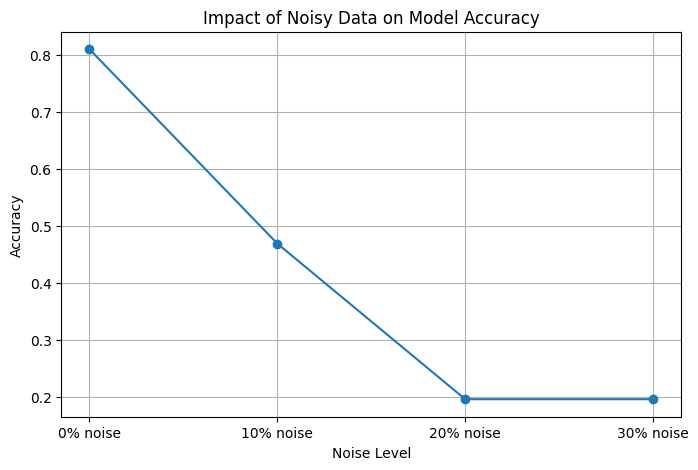

In [26]:
plt.figure(figsize=(8,5))
plt.plot(comparison.index, comparison["accuracy"], marker="o")
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Impact of Noisy Data on Model Accuracy")
plt.grid(True)
plt.savefig("accuracy_noisy_data.png")
plt.show()